In [1]:
print("hello world")

hello world


In [2]:
import numpy as np
import scipy
import sklearn
# import tensorflow as tf

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
# print("TensorFlow:", tf.__version__)

NumPy: 1.26.4
SciPy: 1.13.1
Scikit-learn: 1.5.2


In [3]:
import tensorflow as tf
print(tf.__version__)

2.16.1


In [4]:
## import some basics libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
## Divide the dataset into independent and dependent features

X = dataset.iloc[:, 3:13]
y = dataset.iloc[:, 13]

In [6]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [7]:
# feature Engineering
geography= pd.get_dummies(X['Geography'], dtype=int,drop_first=True)
gender= pd.get_dummies(X['Gender'], dtype=int,drop_first=True)

In [8]:
X=X.drop(['Geography', 'Gender'], axis=1)

In [9]:
pd.concat([X, geography, gender] , axis=1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [10]:
# Splitting the dataset into Training set and Test Set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
X_train

array([[ 0.35649971, -0.6557859 ,  0.34567966, ...,  0.64920267,
         0.97481699,  1.36766974],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  0.64920267,
         0.97481699,  1.6612541 ],
       [-0.96147213, -1.41636539, -0.69539349, ...,  0.64920267,
        -1.02583358, -0.25280688],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -1.54035103,
        -1.02583358, -0.1427649 ],
       [ 0.15932282,  0.3900109 ,  1.03972843, ...,  0.64920267,
        -1.02583358, -0.05082558],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  0.64920267,
         0.97481699, -0.81456811]])

In [13]:
# create the ANN

## Part 2: Now let's create the ANN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.layers import Dropout

In [14]:
# initilize the ANN
classifier=Sequential()

In [28]:
# Adding the input layer
classifier.add(Dense(units=11, activation='relu'))

# Adding the first hidden layer
classifier.add(Dense(units=7, activation='relu'))
classifier.add(Dropout(0.2))

# Adding the second hidden layer
classifier.add(Dense(units=6, activation='relu'))
classifier.add(Dropout(0.3))

# Adding the output layer
classifier.add(Dense(1, activation='sigmoid'))

In [29]:
import tensorflow
opt= tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [30]:
classifier.compile(optimizer=opt, loss='binary_crossentropy',metrics=['accuracy'])

In [31]:
## Early Stopping

import tensorflow as tf

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)

In [32]:
model_history = classifier.fit(
    X_train,
    y_train,
    validation_split=0.33,
    batch_size=10,
    epochs=1000,
    callbacks=[early_stopping]
)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8334 - loss: 0.4416 - val_accuracy: 0.8429 - val_loss: 0.3961
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8427 - loss: 0.3938 - val_accuracy: 0.8387 - val_loss: 0.3965
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8453 - loss: 0.3813 - val_accuracy: 0.8319 - val_loss: 0.4125
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8414 - loss: 0.3845 - val_accuracy: 0.8342 - val_loss: 0.3981
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8468 - loss: 0.3744 - val_accuracy: 0.8421 - val_loss: 0.3885
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8492 - loss: 0.3794 - val_accuracy: 0.8258 - val_loss: 0.4121
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8479 - loss: 0.3731 - val_accuracy: 0.8353 - val_loss: 0.3935
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8489 - loss: 0.3752 - 

In [33]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

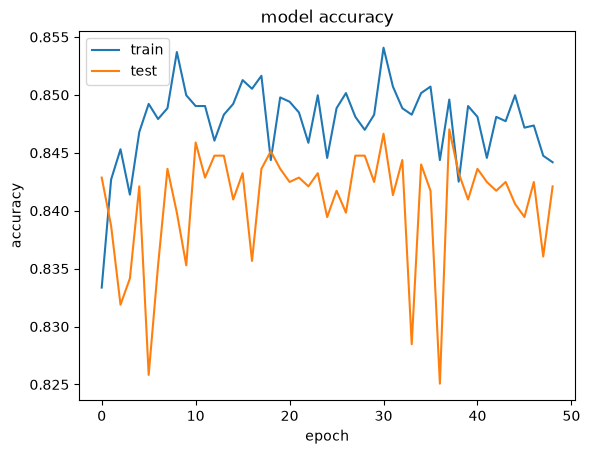

In [34]:
# summarize history for accuracy

plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

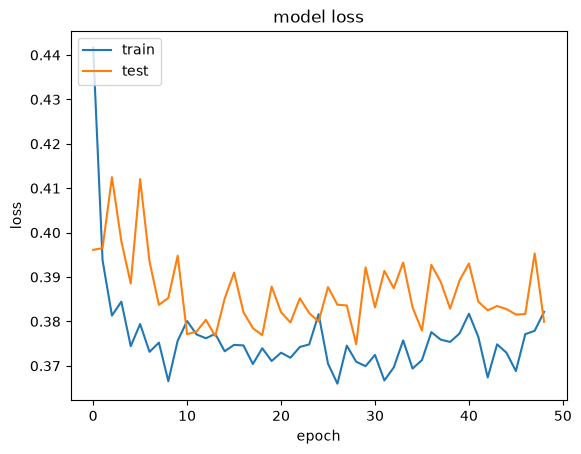

In [35]:
# summarize history for loss

plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [36]:
# Predicting the Test set results

y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [37]:
# Make the Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[1582,   25],
       [ 277,  116]], dtype=int64)

In [25]:
from sklearn.metrics import accuracy_score

score = accuracy_score(y_test, y_pred)
print("Accuracy:", score*100)

Accuracy: 85.0


In [26]:
classifier.save("student_churn_model.keras")

Layer sizes: [8, 11, 7, 6, 1]
Layer 0: weights shape = (8, 11)
Layer 1: weights shape = (11, 7)
Layer 2: weights shape = (7, 6)
Layer 3: weights shape = (6, 1)


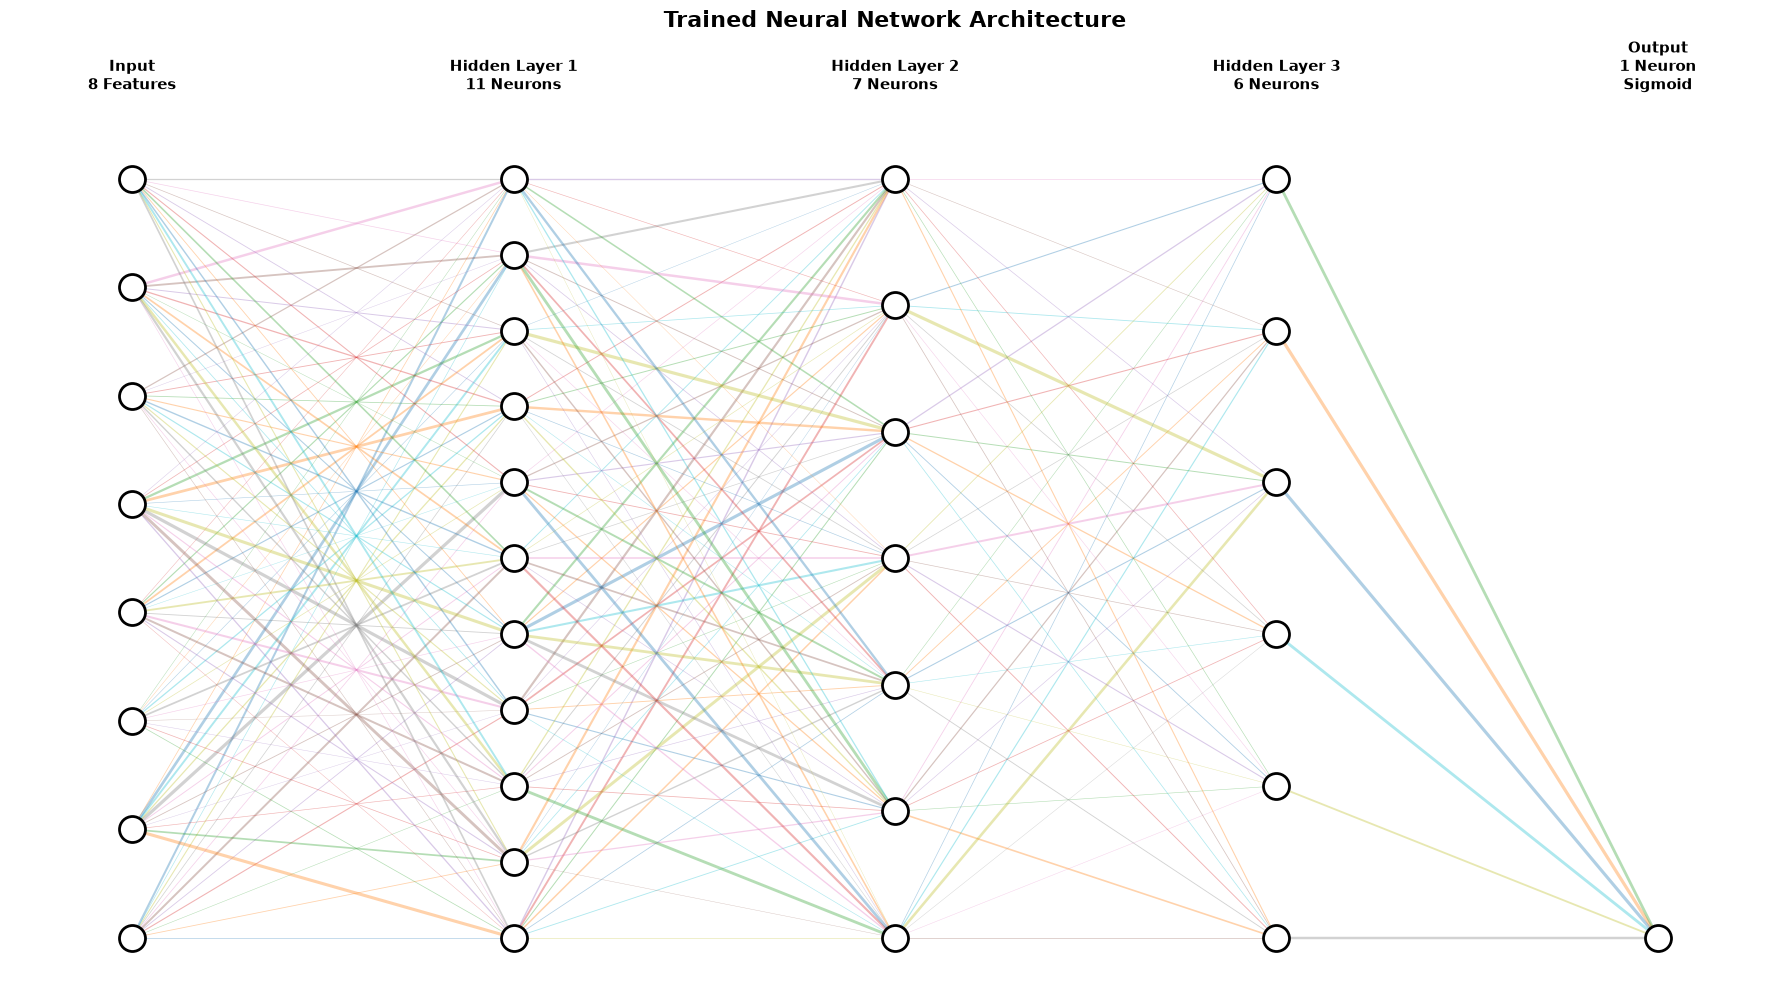

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Get trained weights
weights = classifier.get_weights()

# Get actual layer sizes automatically
layer_sizes = [classifier.input_shape[-1]]

for layer in classifier.layers:
    if hasattr(layer, "units"):
        layer_sizes.append(layer.units)

print("Layer sizes:", layer_sizes)

# Create figure
fig, ax = plt.subplots(figsize=(18, 10))

# X positions
x_positions = np.linspace(0, 1, len(layer_sizes))

# Store neuron positions
positions = []

for layer_index, size in enumerate(layer_sizes):

    x = x_positions[layer_index]

    # Vertical positions
    y = np.linspace(0.05, 0.95, size)

    layer_positions = []

    for neuron_y in y:

        ax.scatter(
            x,
            neuron_y,
            s=350,
            facecolors='white',
            edgecolors='black',
            linewidths=2,
            zorder=3
        )

        layer_positions.append((x, neuron_y))

    positions.append(layer_positions)


# Draw connections using trained weights
for layer_index in range(len(layer_sizes) - 1):

    weight_matrix = weights[layer_index * 2]

    current_layer = positions[layer_index]
    next_layer = positions[layer_index + 1]

    print(
        f"Layer {layer_index}: "
        f"weights shape = {weight_matrix.shape}"
    )

    # Normalize weights
    max_weight = np.max(np.abs(weight_matrix))

    if max_weight == 0:
        max_weight = 1

    # Draw connections
    for i, (x1, y1) in enumerate(current_layer):

        for j, (x2, y2) in enumerate(next_layer):

            weight = weight_matrix[i, j]

            # Thickness based on weight
            linewidth = 0.3 + 2 * abs(weight) / max_weight

            ax.plot(
                [x1, x2],
                [y1, y2],
                linewidth=linewidth,
                alpha=0.35,
                zorder=1
            )


# Layer labels
labels = []

for i, size in enumerate(layer_sizes):

    if i == 0:
        labels.append(f"Input\n{size} Features")

    elif i == len(layer_sizes) - 1:
        labels.append(f"Output\n{size} Neuron\nSigmoid")

    else:
        labels.append(f"Hidden Layer {i}\n{size} Neurons")


# Add labels
for x, label in zip(x_positions, labels):

    ax.text(
        x,
        1.05,
        label,
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )


# Formatting
ax.set_xlim(-0.08, 1.08)
ax.set_ylim(0, 1.12)

ax.axis('off')

plt.title(
    "Trained Neural Network Architecture",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()